# 3c. Model Selection Consensus

**Purpose**: Do grid-search CV (3a) and SBI (3b) agree on which model
(BE vs SC) best describes each animal? If they disagree, which do we
trust and why?

**Protocol**:
1. Load results from 3a (grid-search) and 3b (SBI)
2. Align by animal — compare winner, error magnitudes, confidence
3. Identify discrepancies and diagnose causes
4. Final per-animal classification with confidence rating

In [1]:
%matplotlib inline
from shared_setup import *

import pickle

from behav_utils.plotting.styles import COLOURS, apply_style
apply_style()

## 1. Configuration

In [2]:
# Paths to results from 3a and 3b
GS_RESULTS_DIR = Path('../results/cv')           # grid-search pickles
SBI_RESULTS_DIR = Path('../results/sbi')          # SBI comparison results

# Or load from saved summary files
GS_CSV = GS_RESULTS_DIR / 'cv_comparison_anova.csv'   # from gather_cv_results.py
SBI_PKL = SBI_RESULTS_DIR / 'sbi_comparison_results.pkl'  # from 3b

ALPHA = 0.05  # significance threshold for ANOVA

## 2. Load Grid-Search Results

In [3]:
# ── Load grid-search results ─────────────────────────────────────────────────
HAS_GS = False
gs_df = pd.DataFrame()

# Try summary CSV first (from gather_cv_results.py or cluster pipeline)
if GS_CSV.exists():
    gs_df = pd.read_csv(GS_CSV)
    HAS_GS = True
    print(f'Loaded grid-search summary: {len(gs_df)} animals')
else:
    # Fall back to loading raw pickles and building comparison
    try:
        from analysis.cv_utils import load_cv_pickles, build_long_df, run_anova
        raw = load_cv_pickles(str(GS_RESULTS_DIR))
        if raw:
            long = build_long_df(raw)
            gs_df = run_anova(long)
            HAS_GS = True
            print(f'Built grid-search comparison from pickles: {len(gs_df)} animals')
            # Save for future runs
            gs_df.to_csv(GS_CSV, index=False)
        else:
            print(f'No grid-search results at {GS_RESULTS_DIR}')
            print('Run notebook 3a first.')
    except Exception as e:
        print(f'Could not load grid-search results: {e}')

if HAS_GS:
    cols = [c for c in ['animal_id', 'be_mean', 'sc_mean', 'p_value', 'winner'] if c in gs_df.columns]
    print(gs_df[cols].to_string(index=False))

Loaded grid-search summary: 2 animals
animal_id  be_mean  sc_mean  p_value       winner
     SS01 0.010136 0.010590 0.889815 Inconclusive
     SS04 0.005981 0.006412 0.316145 Inconclusive


## 3. Load SBI Results

In [4]:
# ── Load SBI results ──────────────────────────────────────────────────────────
# 3b saves results per part: {'p1': [list of per-animal dicts], 'p2': [...], ...}
# Or individual part files: sbi_part1.pkl, sbi_part2.pkl, ...
# We merge all parts and take the best result per animal.
HAS_SBI = False
sbi_df = pd.DataFrame()

sbi_all_results = []  # flat list of per-animal dicts across all parts

# Try combined file first
if SBI_PKL.exists():
    with open(SBI_PKL, 'rb') as f:
        sbi_raw = pickle.load(f)

    if isinstance(sbi_raw, dict):
        # Could be {part_name: [list]} or {animal_id: result}
        first_val = next(iter(sbi_raw.values()))
        if isinstance(first_val, list):
            # Format: {'p1': [...], 'p2': [...], ...}
            for part_name, results in sbi_raw.items():
                for r in results:
                    r['source_part'] = part_name
                sbi_all_results.extend(results)
        elif isinstance(first_val, dict):
            # Format: {animal_id: {winner, p, ...}}
            for aid, res in sbi_raw.items():
                res['animal_id'] = aid
                sbi_all_results.append(res)
    elif isinstance(sbi_raw, list):
        sbi_all_results = sbi_raw

# Also try individual part files
if not sbi_all_results:
    SBI_DIR = SBI_PKL.parent
    for part_file in sorted(SBI_DIR.glob('sbi_part*.pkl')):
        with open(part_file, 'rb') as f:
            part_data = pickle.load(f)
        if isinstance(part_data, list):
            for r in part_data:
                r['source_part'] = part_file.stem
            sbi_all_results.extend(part_data)
            print(f'  Loaded {len(part_data)} results from {part_file.name}')

if sbi_all_results:
    # Build summary: one row per animal (use first available part per animal)
    seen = set()
    sbi_rows = []
    for r in sbi_all_results:
        aid = r.get('animal_id', '?')
        if aid in seen:
            continue
        seen.add(aid)
        sbi_rows.append({
            'animal_id': aid,
            'sbi_winner': r.get('winner', '?'),
            'sbi_p': r.get('p', np.nan),
            'sbi_be_mean': r.get('be_mean', np.nan),
            'sbi_sc_mean': r.get('sc_mean', np.nan),
            'source_part': r.get('source_part', '?'),
        })
    sbi_df = pd.DataFrame(sbi_rows)
    HAS_SBI = True
    print(f'SBI: {len(sbi_df)} animals')
    print(sbi_df[['animal_id', 'sbi_winner', 'sbi_be_mean', 'sbi_sc_mean', 'sbi_p']].to_string(index=False))
else:
    print('No SBI results found. Run 3b first.')

SBI: 2 animals
animal_id sbi_winner  sbi_be_mean  sbi_sc_mean    sbi_p
     SS01         BE     0.004334     0.006099 0.001829
     SS04         SC     0.010842     0.002968 0.000076


## 4. Merge & Compare

In [5]:
if HAS_GS and HAS_SBI:
    # Rename GS columns for clarity
    gs_renamed = gs_df.rename(columns={
        'winner': 'gs_winner', 'p_value': 'gs_p',
        'be_mean': 'gs_be_mean', 'sc_mean': 'gs_sc_mean',
    })

    # Merge on animal_id
    merged = pd.merge(
        gs_renamed[['animal_id', 'gs_winner', 'gs_p', 'gs_be_mean', 'gs_sc_mean']],
        sbi_df[['animal_id', 'sbi_winner', 'sbi_p', 'sbi_be_mean', 'sbi_sc_mean']],
        on='animal_id', how='outer', indicator=True,
    )

    # Agreement
    both = merged[merged['_merge'] == 'both'].copy()
    both['agree'] = both['gs_winner'] == both['sbi_winner']

    # Confidence rating
    def confidence(row):
        if row['gs_winner'] == row['sbi_winner']:
            if row['gs_p'] < 0.01 and row['sbi_p'] < 0.01:
                return 'high'
            elif row['gs_p'] < ALPHA and row['sbi_p'] < ALPHA:
                return 'medium'
            else:
                return 'low'
        else:
            return 'disagreement'

    both['confidence'] = both.apply(confidence, axis=1)
    both['final_model'] = both.apply(
        lambda r: r['gs_winner'] if r['agree'] else 'Unresolved', axis=1,
    )

    print("Merged comparison:")
    display_cols = ['animal_id', 'gs_winner', 'gs_p', 'sbi_winner', 'sbi_p',
                    'agree', 'confidence', 'final_model']
    print(both[display_cols].to_string(index=False, float_format='{:.4f}'.format))

    n_agree = both['agree'].sum()
    n_total = len(both)
    print(f"\nAgreement: {n_agree}/{n_total} ({n_agree/n_total:.0%})")
    print(f"Confidence breakdown: {both['confidence'].value_counts().to_dict()}")

elif HAS_GS:
    print("Only grid-search results available.")
    both = gs_df.rename(columns={'winner': 'final_model'}).copy()
    both['confidence'] = both['p_value'].apply(
        lambda p: 'high' if p < 0.01 else ('medium' if p < ALPHA else 'low')
    )
elif HAS_SBI:
    print("Only SBI results available.")
    both = sbi_df.rename(columns={'sbi_winner': 'final_model'}).copy()
else:
    print("No results to compare. Run 3a and/or 3b first.")
    both = pd.DataFrame()

Merged comparison:
animal_id    gs_winner   gs_p sbi_winner  sbi_p  agree   confidence final_model
     SS01 Inconclusive 0.8898         BE 0.0018  False disagreement  Unresolved
     SS04 Inconclusive 0.3161         SC 0.0001  False disagreement  Unresolved

Agreement: 0/2 (0%)
Confidence breakdown: {'disagreement': 2}


## 5. Visualisation

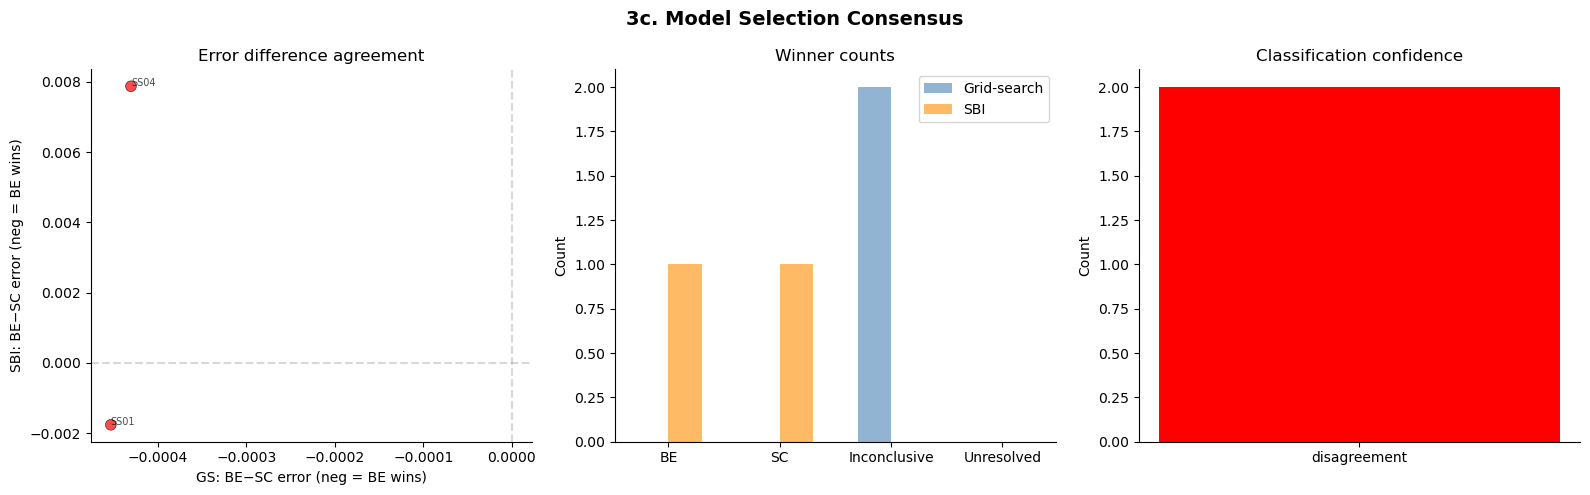

In [6]:
if HAS_GS and HAS_SBI and len(both) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Panel 1: Error comparison scatter ───────────────────────────────────
    ax = axes[0]
    # GS: BE-SC error difference
    both['gs_diff'] = both['gs_be_mean'] - both['gs_sc_mean']  # neg = BE wins
    both['sbi_diff'] = both['sbi_be_mean'] - both['sbi_sc_mean']

    colours = both['agree'].map({True: 'green', False: 'red'})
    ax.scatter(both['gs_diff'], both['sbi_diff'], c=colours, s=60, alpha=0.7,
               edgecolors='k', linewidth=0.5)
    for _, row in both.iterrows():
        ax.annotate(row['animal_id'], (row['gs_diff'], row['sbi_diff']),
                    fontsize=7, alpha=0.7)
    ax.axhline(0, color='grey', ls='--', alpha=0.3)
    ax.axvline(0, color='grey', ls='--', alpha=0.3)
    ax.set_xlabel('GS: BE−SC error (neg = BE wins)')
    ax.set_ylabel('SBI: BE−SC error (neg = BE wins)')
    ax.set_title('Error difference agreement')

    # ── Panel 2: Winner summary ────────────────────────────────────────────
    ax = axes[1]
    cats = ['BE', 'SC', 'Inconclusive', 'Unresolved']
    gs_counts = [len(both[both['gs_winner'] == c]) for c in cats]
    sbi_counts = [len(both[both['sbi_winner'] == c]) for c in cats]
    x = np.arange(len(cats))
    ax.bar(x - 0.15, gs_counts, 0.3, label='Grid-search', color=COLOURS.get('BE', 'steelblue'), alpha=0.6)
    ax.bar(x + 0.15, sbi_counts, 0.3, label='SBI', color=COLOURS.get('SC', 'darkorange'), alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel('Count')
    ax.set_title('Winner counts')
    ax.legend()

    # ── Panel 3: Confidence breakdown ──────────────────────────────────────
    ax = axes[2]
    conf_counts = both['confidence'].value_counts()
    conf_colours = {'high': 'green', 'medium': 'gold', 'low': 'orange', 'disagreement': 'red'}
    bars = ax.bar(conf_counts.index, conf_counts.values,
                  color=[conf_colours.get(c, 'grey') for c in conf_counts.index])
    ax.set_ylabel('Count')
    ax.set_title('Classification confidence')

    fig.suptitle('3c. Model Selection Consensus', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Diagnose Disagreements

In [7]:
if HAS_GS and HAS_SBI and len(both) > 0:
    disagree = both[~both['agree']]
    if len(disagree) > 0:
        print(f"\n{len(disagree)} disagreements to investigate:\n")
        for _, row in disagree.iterrows():
            print(f"  {row['animal_id']}:")
            print(f"    GS:  {row['gs_winner']} (BE={row['gs_be_mean']:.5f}, "
                  f"SC={row['gs_sc_mean']:.5f}, p={row['gs_p']:.3g})")
            print(f"    SBI: {row['sbi_winner']} (BE={row['sbi_be_mean']:.5f}, "
                  f"SC={row['sbi_sc_mean']:.5f}, p={row['sbi_p']:.3g})")
            gs_margin = abs(row['gs_be_mean'] - row['gs_sc_mean'])
            sbi_margin = abs(row['sbi_be_mean'] - row['sbi_sc_mean'])
            print(f"    GS margin: {gs_margin:.5f}, SBI margin: {sbi_margin:.5f}")
            if gs_margin < 0.001 or sbi_margin < 0.001:
                print(f"    → Very small margin — borderline animal")
            print()
    else:
        print("Perfect agreement across all animals.")


2 disagreements to investigate:

  SS01:
    GS:  Inconclusive (BE=0.01014, SC=0.01059, p=0.89)
    SBI: BE (BE=0.00433, SC=0.00610, p=0.00183)
    GS margin: 0.00045, SBI margin: 0.00177
    → Very small margin — borderline animal

  SS04:
    GS:  Inconclusive (BE=0.00598, SC=0.00641, p=0.316)
    SBI: SC (BE=0.01084, SC=0.00297, p=7.65e-05)
    GS margin: 0.00043, SBI margin: 0.00787
    → Very small margin — borderline animal



### 6b. Visual Disagreement Diagnostics

For each disagreeing animal, show the actual update matrix alongside
the best-fit model predictions from each method. This reveals *why*
the methods disagree — different sensitivity to specific UM features.

In [8]:
# Load real data for detailed comparison
from behav_utils.data.loading import load_experiment
from behav_utils.data.selection import select_sessions
from behav_utils.analysis.update_matrix import (
    compute_update_matrix, compute_update_matrix_from_sessions,
)
from behav_utils.plotting.update_matrix import (
    plot_update_matrix, plot_phase_update_matrices,
)
from behav_utils.plotting.psychometric import plot_psychometric_overlay

CONFIG_PATH = Path('../config.yaml')
STAGE = 'Full_Task_Cont'

try:
    experiment = load_experiment(CONFIG_PATH)
    HAS_RAW = True
    print(f'Loaded {len(experiment.animal_ids)} animals for diagnostics')
except Exception as e:
    HAS_RAW = False
    print(f'Could not load raw data: {e}')

Loaded 12 animals, 433 total sessions
Loaded 12 animals for diagnostics



  SS01: GS→Inconclusive, SBI→BE
  GS margins: BE=0.01014, SC=0.01059
  SBI margins: BE=0.00433, SC=0.00610


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


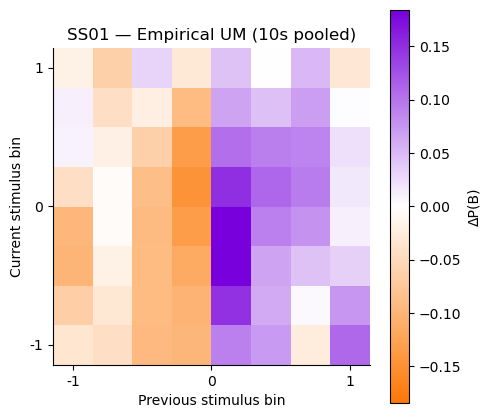

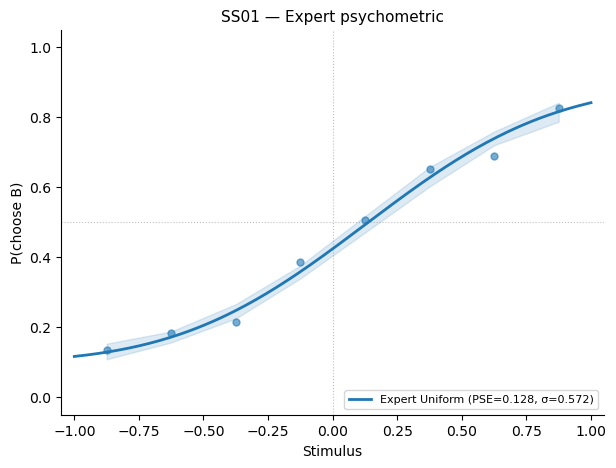

  UM profile range: 0.2276
  Valid UM columns: 8/8
  → GS margin very small — SBI classification more decisive, prefer SBI.

  SS04: GS→Inconclusive, SBI→SC
  GS margins: BE=0.00598, SC=0.00641
  SBI margins: BE=0.01084, SC=0.00297


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


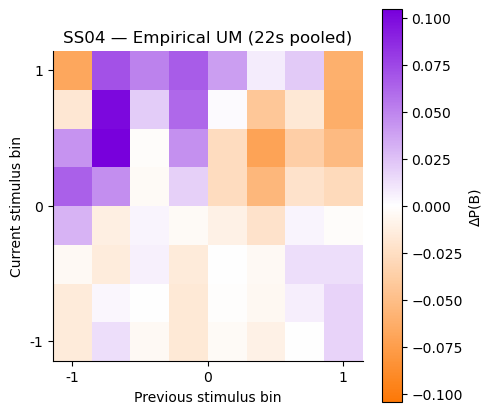

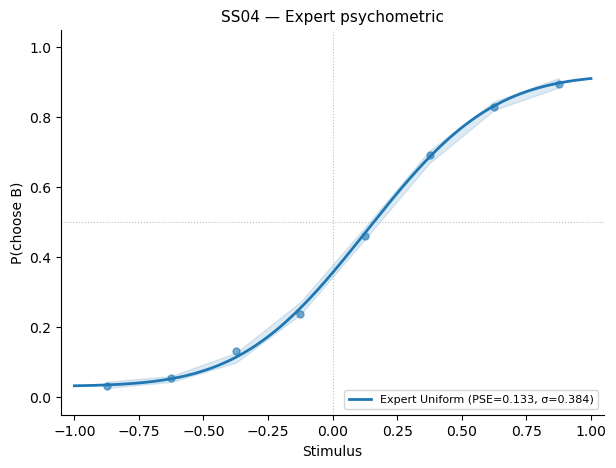

  UM profile range: 0.0643
  Valid UM columns: 8/8
  → GS margin very small — SBI classification more decisive, prefer SBI.


In [9]:
if HAS_GS and HAS_SBI and HAS_RAW and len(both) > 0:
    disagree = both[~both['agree']]

    if len(disagree) == 0:
        print('No disagreements — all animals classified consistently.')
    else:
        for _, row in disagree.iterrows():
            aid = row['animal_id']
            print(f"\n{'='*60}")
            print(f"  {aid}: GS→{row['gs_winner']}, SBI→{row['sbi_winner']}")
            print(f"  GS margins: BE={row['gs_be_mean']:.5f}, SC={row['gs_sc_mean']:.5f}")
            print(f"  SBI margins: BE={row['sbi_be_mean']:.5f}, SC={row['sbi_sc_mean']:.5f}")

            try:
                animal = experiment.get_animal(aid)
            except KeyError:
                print(f'  Animal {aid} not found in data — skipping')
                continue

            # Get expert sessions
            expert = select_sessions(
                animal, stage=STAGE, distribution='Uniform',
                min_accuracy=0.70, last_fraction=0.50,
            )
            if len(expert) < 3:
                print(f'  Too few expert sessions ({len(expert)}) — skipping')
                continue

            # ── 1. Data update matrix ────────────────────────────────────
            um_data, cm_data, info_data = compute_update_matrix_from_sessions(
                expert, method='pool',
            )

            fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
            plot_update_matrix(
                um_data, ax=ax,
                title=f'{aid} — Empirical UM ({info_data["n_sessions"]}s pooled)',
            )
            plt.tight_layout()
            plt.show()

            # ── 2. Psychometric curve ────────────────────────────────────
            fig, ax, psych_info = plot_psychometric_overlay(
                {'Expert Uniform': expert},
                mode='pooled', n_bootstrap=200,
                title=f'{aid} — Expert psychometric',
            )
            plt.show()

            # ── 3. Interpretation ────────────────────────────────────────
            # Check for ambiguous UM features
            profile = np.nanmean(um_data, axis=0)
            profile_range = np.nanmax(profile) - np.nanmin(profile)
            n_valid_cols = np.sum(~np.all(np.isnan(um_data), axis=0))

            print(f'  UM profile range: {profile_range:.4f}')
            print(f'  Valid UM columns: {n_valid_cols}/8')

            if profile_range < 0.02:
                print(f'  → Very flat profile — weak serial dependence. '
                      f'Neither model fits well; classification unreliable.')
            if n_valid_cols < 6:
                print(f'  → Many NaN columns — insufficient data in '
                      f'extreme bins. MSE comparison unreliable.')

            gs_margin = abs(row['gs_be_mean'] - row['gs_sc_mean'])
            sbi_margin = abs(row['sbi_be_mean'] - row['sbi_sc_mean'])
            if gs_margin < 0.001 and sbi_margin < 0.001:
                print(f'  → Both methods show tiny margins — '
                      f'genuinely ambiguous animal.')
            elif gs_margin < 0.001:
                print(f'  → GS margin very small — SBI classification '
                      f'more decisive, prefer SBI.')
            elif sbi_margin < 0.001:
                print(f'  → SBI margin very small — GS classification '
                      f'more decisive, prefer GS.')

elif not HAS_RAW:
    print('Raw data not available — text diagnostics only (see cell above).')

## 7. Final Classification Table

In [10]:
if len(both) > 0:
    final = both[['animal_id', 'final_model', 'confidence']].copy()
    print("Final model assignments:")
    print(final.to_string(index=False))

    # Save
    # results_dir = Path('../results')
    # results_dir.mkdir(parents=True, exist_ok=True)
    # final.to_csv(results_dir / 'model_classification_consensus.csv', index=False)
    # print(f"\nSaved to {results_dir / 'model_classification_consensus.csv'}")

Final model assignments:
animal_id final_model   confidence
     SS01  Unresolved disagreement
     SS04  Unresolved disagreement


## Interpretation

**High agreement**: Both methods robustly classify the same animals the same way.
This is the best case — the classification is method-independent.

**Disagreements on borderline animals**: Small error margins in both methods.
These animals may genuinely lie between the two model classes, or the data
may be insufficient for classification. Report as 'Unresolved'.

**Systematic disagreement**: One method consistently picks BE where the other
picks SC. This would indicate a methodological bias — investigate whether
the SBI stat set or the grid-search resolution is driving the difference.

**Note**: The SBI results should be from the bug-fixed `cv_um_comparison`
(block-level splitting, not trial-level). If using pre-fix results, re-run
3b first.